%%

In [ ]:
# Installing libraries and dataset
!pip install transformers "datasets<3.0.0" evaluate wandb pandas scikit-learn accelerate librosa soundfile audiomentations

In [ ]:
from datetime import datetime
current_time_str = datetime.now().strftime("%Y%m%d_%H%M%S")

In [ ]:
print(f"Current time: {current_time_str}")
# %%
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Union
from collections import Counter

In [ ]:
# Importing Libraries
import pandas as pd
import numpy as np
import torch
import wandb

In [ ]:
from datasets import (
    load_dataset, 
    Audio
    # load_from_disk, 
    # DatasetDict, 
    # concatenate_datasets, 
)

%%

In [ ]:
# Classes which are used to load the model and train it.
from transformers import (
    AutoModelForAudioClassification, 
    AutoFeatureExtractor, 
    Wav2Vec2Config,
    AutoConfig,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed
)

In [ ]:
from huggingface_hub import login # Helps in pushing trained model to hugging face hub.

import Hugging Face libraries

In [ ]:
import evaluate

%%<br>
check if there GPU

In [ ]:
print("Check if GPU available:") # Checking if a GPU is available.
print("MPS available:", torch.backends.mps.is_available())

%%<br>
login to Hugging Face

In [ ]:
login(token="") # Hugging face key

%%<br>
login to WANDB

In [ ]:
# Weights and Biases key
wandb.login(key="") 

%%

In [ ]:
#model_id = "facebook/mms-300m"
model_id = "utter-project/mHuBERT-147" # Model Selected
#model_id = "facebook/wav2vec2-xls-r-300m"

%%

In [ ]:
# Converts raw audio signals in numerical values which model can unserstand.
feature_extractor = AutoFeatureExtractor.from_pretrained(
    model_id, 
    do_normalize=True,
    return_attention_mask=True,
)

%%

In [ ]:
dataset = load_dataset("badrex/nnti-dataset-full") #Loading Dataset

%%<br>
check the strucutre of the dataset object 

In [ ]:
print(f"dataset['train']: {dataset['train']}") # Checking dataset structure

%%<br>
check the strucutre of one training sample (before decoding)

In [ ]:
print(f"dataset['train'][0]: {dataset['train'][0]}")

%%<br>
shuffle the dataset

In [ ]:
# Shuffling dataset to prevent model from learning patterns as a result of ordering.
train_ds = dataset['train'].shuffle(seed=42)
valid_ds = dataset['validation'].shuffle(seed=42)

resample to 16kHz

In [ ]:
# Resampling all audio files to 16KHz.
train_ds = train_ds.cast_column("audio_filepath", Audio(sampling_rate=16000))
valid_ds = valid_ds.cast_column("audio_filepath", Audio(sampling_rate=16000))

%%<br>
based on the model typel, set input features key

In [ ]:
if model_id == "facebook/w2v-bert-2.0":
    input_features_key = "input_features"
else:
    input_features_key = "input_values"

%%

In [ ]:
max_duration = 10 # preprocessing audio limit is extended to 10 seconds.

%%<br>
get the set of languages

In [ ]:
LABELS = train_ds.unique('language') # Extracting unique languages from the dataset.

In [ ]:
sorted_labels = sorted(l.upper() for l in LABELS) 
print(f"Languages: {sorted_labels}")

In [ ]:
# Converting language names into integers Id's
str_to_int = {
    s: i for i, s in enumerate(LABELS)
}

In [ ]:
# Audio augmentation is applied to modify audio.
from audiomentations import Compose, PitchShift, AddGaussianNoise, TimeStretch

augmenter = Compose([
    PitchShift(min_semitones=-4, max_semitones=4, p=0.5), 
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5), 
    TimeStretch(min_rate=0.8, max_rate=1.2, p=0.5) 
])

%%

In [ ]:
# Preparing dataset before training.
def preprocess_function(examples, augment=False):
    if augment: #If enabled, apply augmentation technique.
        audio_arrays = [
            augmenter(samples=x["array"], sample_rate=16000)
            for x in examples["audio_filepath"]
        ]
    else:
        audio_arrays = [
            x["array"]
            for x in examples["audio_filepath"]
        ]

    inputs = feature_extractor( # Converting audio to model input format
        audio_arrays,
        sampling_rate=feature_extractor.sampling_rate,
        truncation=True,
        max_length=int(feature_extractor.sampling_rate * max_duration),
        return_attention_mask=True,
    )

    inputs["label"] = [str_to_int[x] for x in examples["language"]]
    inputs[input_features_key] = [np.array(x) for x in inputs[input_features_key]]
    inputs["length"] = [len(f) for f in inputs[input_features_key]]

    return inputs

%%

In [ ]:
keep_cols = ['speaker_id', 'language']

%% [markdown]<br>
## encode the train and valid splits 

In [ ]:
# Preprocessing training and validation datasets.
train_ds_encoded = train_ds.map(
    lambda x: preprocess_function(x, augment=True),
    remove_columns=[c for c in train_ds.column_names if c not in keep_cols],
    batched=True,
    batch_size=32,
    #num_proc=8,
)

In [ ]:
valid_ds_encoded = valid_ds.map(
    lambda x: preprocess_function(x, augment=False),
    remove_columns=[c for c in valid_ds.column_names if c not in keep_cols],
    batched=True,
    batch_size=32,
    #num_proc=8,
)

%%

In [ ]:
int_to_str = {
    i: s for s, i in str_to_int.items()
}

In [ ]:
num_labels = len(int_to_str)

%%

In [ ]:
config = AutoConfig.from_pretrained(model_id)

In [ ]:
config.num_labels=num_labels
config.label2id=str_to_int
config.id2label=int_to_str

In [ ]:
do_apply_dropout = True # Applying dropout.

check if dropout is enabled

In [ ]:
if do_apply_dropout:
    config.hidden_dropout = 0.1           # Dropout for hidden states
    config.attention_dropout = 0.1        # Dropout in attention layers
    config.activation_dropout = 0.1       # Dropout after activation functions
    config.feat_proj_dropout = 0.1   

%%<br>
spoken language ID (SLID) model

In [ ]:
# Loading the pretrained audio classification model.
slid_model = AutoModelForAudioClassification.from_pretrained(
    model_id,
    config=config,
)

%%<br>
create collator for padding

In [ ]:
class AudioDataCollator:
    def __init__(self, feature_extractor):
        self.feature_extractor = feature_extractor
    
    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        # preparing the batch dict in the format expected by the feature extractor
        batch = {
            input_features_key: [f[input_features_key] for f in features],
            "attention_mask": [f["attention_mask"] for f in features]
        }
        
        # using the feature extractor's native padding
        batch = self.feature_extractor.pad(
            batch,
            padding=True,
            return_tensors="pt"
        )
        
        # adding labels
        batch["labels"] = torch.tensor(
            [f["label"] for f in features], 
            dtype=torch.long
        )
        
        return batch

%%

In [ ]:
data_collator = AudioDataCollator(feature_extractor)

%%

In [1]:
# Training parameters
batch_size = 2
gradient_accumulation_steps = 16
num_train_epochs = 7
lr = 0.00002

%%

In [ ]:
wandb.init(project="Indic-SLID", name=f"SLID_{model_id}_{lr}_{current_time_str}")

%%

In [ ]:
training_args = TrainingArguments(
    report_to="wandb", 
    logging_steps=1, 
    per_device_train_batch_size=batch_size, 
    per_device_eval_batch_size=batch_size,    
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps", 
    save_steps=100,
    learning_rate=lr,
    gradient_accumulation_steps=gradient_accumulation_steps,
    num_train_epochs=num_train_epochs,
    weight_decay=0.04,
    warmup_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True, 
    save_total_limit=2, 
    fp16=False,
    push_to_hub=True,
    hub_model_id="Saad-Wazir24/indic-slid-mhubert",
    hub_strategy="end",
    use_cpu=False,               
    dataloader_pin_memory=False, 
)

%%<br>
load evaluation metrics

In [ ]:
accuracy_metric = evaluate.load("accuracy")

In [ ]:
def compute_metrics(eval_pred):
    """Computes accuracy on a batch of predictions"""
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return accuracy_metric.compute(
        predictions=predictions, 
        references=eval_pred.label_ids
    )

%%

In [ ]:
trainer = Trainer(
    slid_model,
    training_args,
    train_dataset=train_ds_encoded,
    eval_dataset=valid_ds_encoded,
    processing_class=feature_extractor,
    data_collator=data_collator,  
    compute_metrics=compute_metrics,
)

%%

In [ ]:
print("Train loop starting...") # Initializing training
trainer.train()

%%

In [ ]:
print("Final evaluation starting...")
trainer.evaluate()

In [ ]:
trainer.push_to_hub() # Pushing model to hugging face account.
feature_extractor.push_to_hub("Saad-Wazir24/indic-slid-mhubert")

In [2]:
from transformers import AutoModelForAudioClassification, AutoFeatureExtractor
# Loading both models for comparison.
baseline_model = AutoModelForAudioClassification.from_pretrained(
    "Saad-Wazir24/indic-slid-mhubert"
)

improved_model = AutoModelForAudioClassification.from_pretrained(
    "Saad-Wazir24/indic-slid-mhubert-task2"
)

feature_extractor = AutoFeatureExtractor.from_pretrained(
    "Saad-Wazir24/indic-slid-mhubert-task2"
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

In [3]:
from datasets import load_dataset, Audio

dataset = load_dataset("badrex/nnti-dataset-full")

valid_ds = dataset["validation"]
valid_ds = valid_ds.cast_column("audio_filepath", Audio(sampling_rate=16000))

README.md:   0%|          | 0.00/679 [00:00<?, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/382M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/383M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/311M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8689 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3300 [00:00<?, ? examples/s]

In [11]:
LABELS = dataset["train"].unique("language")

str_to_int = {s: i for i, s in enumerate(LABELS)}

int_to_str = {i: s for s, i in str_to_int.items()}

In [16]:
def preprocess_eval(examples):

    audio_arrays = [x["array"] for x in examples["audio_filepath"]]

    inputs = feature_extractor(
        audio_arrays,
        sampling_rate=16000,
        truncation=True,
        max_length=16000*10,
        return_attention_mask=True,
    )

    inputs["label"] = [str_to_int[x] for x in examples["language"]]

    return inputs

In [17]:
valid_ds_encoded = valid_ds.map(
    preprocess_eval,
    batched=True
)

Map:   0%|          | 0/3300 [00:00<?, ? examples/s]

In [23]:
class AudioDataCollator:
    def __init__(self, feature_extractor):
        self.feature_extractor = feature_extractor
    
    def __call__(self, features):

        batch = {
            "input_values": [f["input_values"] for f in features],
            "attention_mask": [f["attention_mask"] for f in features]
        }

        batch = feature_extractor.pad(
            batch,
            padding=True,
            return_tensors="pt"
        )

        batch["labels"] = torch.tensor(
            [f["label"] for f in features],
            dtype=torch.long
        )

        return batch


data_collator = AudioDataCollator(feature_extractor)

In [24]:
from transformers import Trainer

baseline_trainer = Trainer(
    model=baseline_model,
    data_collator=data_collator
)

improved_trainer = Trainer(
    model=improved_model,
    data_collator=data_collator
)

In [25]:
import torch
baseline_preds = baseline_trainer.predict(valid_ds_encoded)
improved_preds = improved_trainer.predict(valid_ds_encoded)

In [27]:
import numpy as np
from sklearn.metrics import confusion_matrix

y_true = baseline_preds.label_ids
y_pred_baseline = np.argmax(baseline_preds.predictions, axis=1)

cm_baseline = confusion_matrix(y_true, y_pred_baseline)

In [28]:
y_pred_improved = np.argmax(improved_preds.predictions, axis=1)

cm_improved = confusion_matrix(y_true, y_pred_improved)

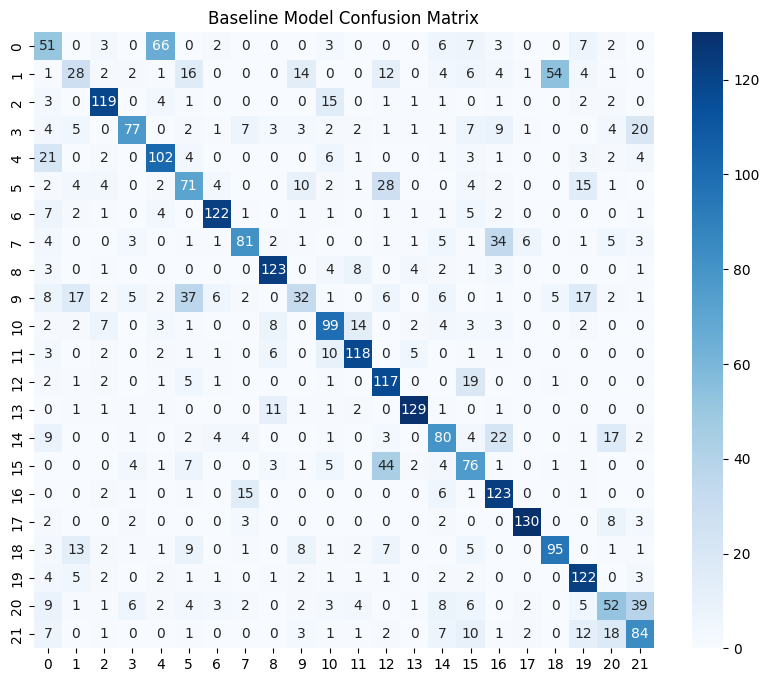

In [29]:
import seaborn as sns # Confusion matrices are generated to check if model predicts each language correctly.
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(cm_baseline, annot=True, fmt="d", cmap="Blues")
plt.title("Baseline Model Confusion Matrix")
plt.show()

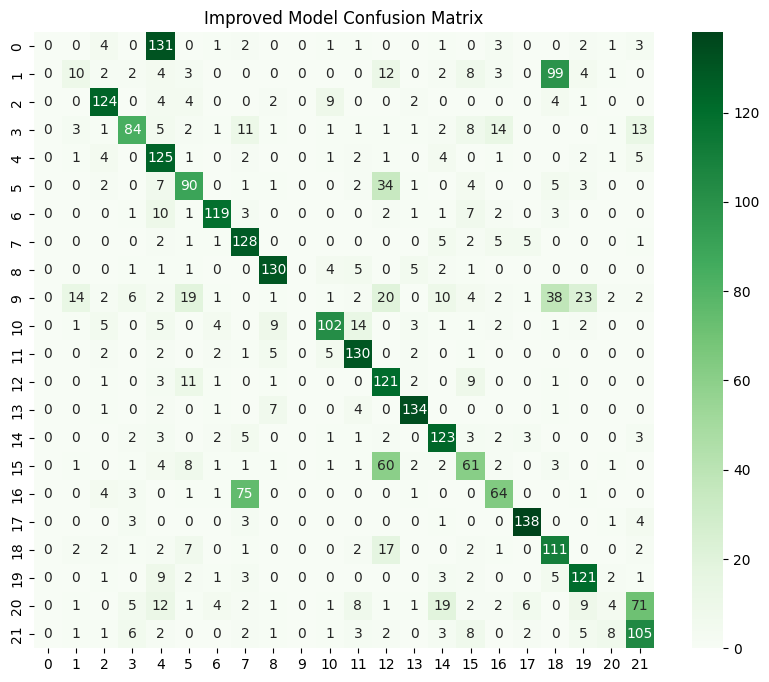

In [30]:
plt.figure(figsize=(10,8))
sns.heatmap(cm_improved, annot=True, fmt="d", cmap="Greens")
plt.title("Improved Model Confusion Matrix")
plt.show()

In [33]:
from sklearn.metrics import classification_report
import numpy as np

# labeling names in correct order
language_names = [int_to_str[i] for i in range(len(int_to_str))]

# BASELINE classification report
y_true = baseline_preds.label_ids
y_pred_baseline = np.argmax(baseline_preds.predictions, axis=1)
print("Baseline model Classification Report")
baseline_report = classification_report(
    y_true,
    y_pred_baseline,
    target_names=language_names
)
print(baseline_report)

with open("baseline_classification_report.txt", "w") as f:
    f.write(baseline_report)

# Fine Tuned model classification report 
y_pred_improved = np.argmax(improved_preds.predictions, axis=1)

print(" Fine-Tuned model Classification Report")
improved_report = classification_report(
    y_true,
    y_pred_improved,
    target_names=language_names
)
print(improved_report)

with open("Fine-Tuned model.txt", "w") as f:
    f.write(improved_report)

Baseline model Classification Report
              precision    recall  f1-score   support

     konkani       0.35      0.34      0.35       150
       hindi       0.35      0.19      0.24       150
    sanskrit       0.77      0.79      0.78       150
     santali       0.75      0.51      0.61       150
     marathi       0.53      0.68      0.59       150
      sindhi       0.43      0.47      0.45       150
    kashmiri       0.84      0.81      0.82       150
        bodo       0.70      0.54      0.61       150
       tamil       0.78      0.82      0.80       150
    maithili       0.41      0.21      0.28       150
     kannada       0.63      0.66      0.64       150
      telugu       0.77      0.79      0.78       150
     punjabi       0.52      0.78      0.63       150
   malayalam       0.88      0.86      0.87       150
      nepali       0.57      0.53      0.55       150
       dogri       0.47      0.51      0.49       150
    manipuri       0.58      0.82      0.68 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [35]:
baseline_model.config.output_hidden_states = True
improved_model.config.output_hidden_states = True

In [36]:
from torch.utils.data import DataLoader

def extract_embeddings(model, dataset, collator, batch_size=16):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    loader = DataLoader(dataset, batch_size=batch_size, collate_fn=collator)
    
    embeddings = []
    labels = []

    model.eval()

    with torch.no_grad():
        for batch in loader:

            input_values = batch["input_values"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            batch_labels = batch["labels"].to(device)

            outputs = model(
                input_values=input_values,
                attention_mask=attention_mask,
                output_hidden_states=True
            )

            last_hidden = outputs.hidden_states[-1]

            # Mean pooling
            emb = last_hidden.mean(dim=1)

            embeddings.append(emb.cpu().numpy())
            labels.append(batch_labels.cpu().numpy())

    embeddings = np.concatenate(embeddings)
    labels = np.concatenate(labels)

    return embeddings, labels

In [ ]:
baseline_embeddings, labels = extract_embeddings(
    baseline_model,
    valid_ds_encoded,
    data_collator
)

improved_embeddings, _ = extract_embeddings(
    improved_model,
    valid_ds_encoded,
    data_collator
)

In [19]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)

baseline_tsne = tsne.fit_transform(baseline_embeddings)

improved_tsne = tsne.fit_transform(improved_embeddings)

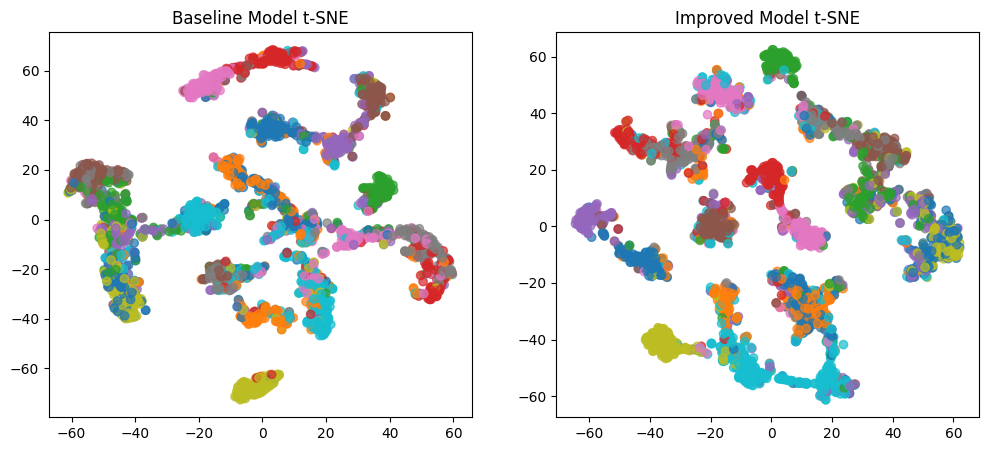

In [20]:
plt.figure(figsize=(12,5)) # Plotiing T-SNE Graphs.

plt.subplot(1,2,1)
plt.scatter(
    baseline_tsne[:,0],
    baseline_tsne[:,1],
    c=labels,
    cmap="tab10",
    alpha=0.7
)
plt.title("Baseline Model t-SNE")

plt.subplot(1,2,2)
plt.scatter(
    improved_tsne[:,0],
    improved_tsne[:,1],
    c=labels,
    cmap="tab10",
    alpha=0.7
)
plt.title("Improved Model t-SNE")

plt.show()